# 8 · Integrated Cleaning-Plan Optimization (แผนล้างเดียวที่ปฏิบัติได้จริง)

**ทำไมมี notebook นี้:** เดิมมีแผนล้าง 2 ชุดแยกกัน — v1 (T\* อิสระต่อ HX) กับ v2 (network moving-window) —
ทำให้ดูไม่สอดคล้องและตัดสินใจยาก. Notebook นี้รวมเป็น **แผนเดียวที่แนะนำ** โดยชั่งพร้อมกันทุกด้านที่การล้างจริงต้องคิด:

| ด้าน | ตัวแปร | มาจาก |
|---|---|---|
| **ความคุ้มค่า** (economics) | net saving/ปี, payback[วัน] | สูตรพลังงานโรงงาน × ΔCIT วัดจริง ÷ ค่าล้างต่อ HX |
| **ประสิทธิภาพ/ความรุนแรง** (efficiency) | fouling rate r [°C/วัน] (robust, reliable) | `Fouling_Rate_By_Run.csv` (§11 methodology) |
| **ความเป็นไปได้ในการ operate** (feasibility) | bypass/spare, เพดาน 4 ครั้ง/ปี, ทีมล้าง ≤N/เดือน, TAM-only, ช่วงห่างขั้นต่ำ | `cleaning_logistics.json` + constraint |
| **ความวิกฤต** (criticality) | safety, ตำแหน่งในเทรน (ยิ่งท้าย=ยิ่งร้อน=เสี่ยง), worsening | `hx_ranking.json` |

**ตรรกะ:** แก้ตารางล้างทั้งเครือข่ายด้วย constrained moving-window optimizer (ต้นทุนพลังงานสะสม + ค่าล้าง ต่ำสุด
ภายใต้ข้อจำกัด operate จริง) → ได้ตารางที่ **ทำได้จริง**. เมื่อทรัพยากรชนกัน จัดลำดับด้วย **net-saving ถ่วงด้วยความเสี่ยง**
(คุ้มค่าก่อน แต่ HX วิกฤต/safety ได้ลำดับสูงขึ้น). T\* อิสระเหลือเป็น "ค่าอ้างอิงเชิงทฤษฎีต่อ HX" เท่านั้น.

> ทุกเซลล์แสดงข้อมูลนำเข้า + การตรวจความสมเหตุสมผล เพื่อให้ตามผลและจับจุดผิดได้.

In [1]:
import os, sys, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = Path(os.environ.get('CPHT_DATA_DIR', r'C:\Desktop\Bangchak Internship 2026\Data'))
DASH = REPO / 'dashboard' / 'data'
sys.path.append(str(REPO / 'notebooks'))
sys.path.append(str(REPO / 'pipeline'))
import nb_audit as A

def load(name, default=None):
    p = DASH / name
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else default

pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)
print('REPO :', REPO); print('DATA :', DATA)

# per-HX cleaning-cost overrides from the dashboard's "คำนวณใหม่" button
# (backend/server.py writes this before re-running this notebook). Optional —
# absent file / missing HX just falls back to economics.json's baseline cost.
COST_OVERRIDES = load('cost_overrides.json', {}) or {}
if COST_OVERRIDES:
    print(f'cost overrides active for {len(COST_OVERRIDES)} HX:', COST_OVERRIDES)

REPO : C:\Desktop\Bangchak Internship 2026\furnace-optimization
DATA : C:\Desktop\Bangchak Internship 2026\Data


## 1 · โหลด & ตรวจข้อมูลนำเข้า (data sanity — จับจุดผิดตรงนี้ก่อน)

โหลด 4 แหล่ง แล้วตรวจว่าข้อมูลพร้อมใช้: fouling rate ที่ **reliable** (ผ่านเกณฑ์ฟิสิกส์ slope<0),
economics (ΔCIT วัดจริง/โมเดล), logistics (ล้าง online ได้ไหม), ranking (safety/ตำแหน่ง).

In [2]:
fr    = pd.read_csv(DATA / 'Fouling_Rate_By_Run.csv')
econ  = load('economics.json', {})
logi  = load('cleaning_logistics.json', {'hx': []})
rank  = {r['HX']: r for r in load('hx_ranking.json', [])}
eor   = load('end_of_run.json', {'hx': {}})

# --- sanity checks (visible) ---
A.plausibility_checks([
    ('fouling: reliable runs exist',           pd.Series([fr['reliable'].sum() > 0])),
    ('fouling: NO reliable run has slope>=0',   ~((fr['reliable']) & (fr['dUrel_per_day'] >= 0))),
    ('economics: per_hx present',              pd.Series([len(econ.get('per_hx', [])) > 0])),
])
rel = fr[fr['reliable'] == True]                                   # noqa: E712
print(f"\nfouling runs: {len(fr)} total · {len(rel)} reliable ({len(rel)/max(len(fr),1)*100:.0f}%)")
print('reliable dUrel/month range: [%.3f .. %.3f]' % (rel.dUrel_per_month.min(), rel.dUrel_per_month.max()))
print('rate_flag breakdown:', fr.rate_flag.value_counts().to_dict())

── Plausibility checks ──
   ✓ all checks passed

fouling runs: 125 total · 69 reliable (55%)
reliable dUrel/month range: [-0.268 .. -0.002]
rate_flag breakdown: {'ok': 69, 'insufficient_span': 49, 'flat_no_signal': 5, 'positive_slope_throughput': 2}


## 2 · ตารางตัดสินใจต่อ HX (decision inputs)

รวมทุกตัวแปรของแต่ละ HX ไว้ที่เดียว. **fouling rate ต่อ HX** ใช้ค่า reliable ล่าสุด (current run ก่อน,
ไม่มีก็รอบ reliable ล่าสุด). HX ที่ไม่มีรอบ reliable เลย (เช่น spare E112C บางกรณี) จะ inherit จากคู่ในตำแหน่งเดียวกัน.

In [3]:
# spare-shell partners share one physical position → same fouling environment
PARTNER = {'E113A': 'E112C', 'E112C': 'E113A'}

def latest_reliable_rate(hx):
    g = rel[rel.HX == hx].sort_values('Run')
    if len(g):
        row = g.iloc[-1]
        # prefer the "current" recent-window rate when available & negative
        r = row.get('dUrel_per_day_recent')
        r = r if (pd.notna(r) and r < 0) else row['dUrel_per_day']
        return float(r), 'own', float(row['dUrel_per_month'])
    return None, None, None

logi_by = {r['HX']: r for r in logi.get('hx', [])}
econ_by_raw = {r['HX']: r for r in econ.get('per_hx', [])}
# apply per-HX cost overrides (from the dashboard's "คำนวณใหม่" button) here, in-memory,
# so every downstream calc (T*, priority, the actual optimizer schedule in §5) uses them.
econ_by = {}
for hx, e in econ_by_raw.items():
    e = dict(e)
    if hx in COST_OVERRIDES:
        e['cleaning_cost'] = COST_OVERRIDES[hx]
    econ_by[hx] = e

rows = []
for hx in sorted(set(list(logi_by) + list(econ_by) + list(rank))):
    r_day, src, r_month = latest_reliable_rate(hx)
    if r_day is None and hx in PARTNER:                     # inherit partner's environment
        r_day, src, r_month = latest_reliable_rate(PARTNER[hx])
        if r_day is not None: src = f'partner:{PARTNER[hx]}'
    lg = logi_by.get(hx, {}); e = econ_by.get(hx, {}); rk = rank.get(hx, {})
    online = bool(lg.get('bypass')) or bool(lg.get('swap_capable'))
    duty_frac = lg.get('duty_fraction', 1.0) if lg.get('duty_fraction') is not None else 1.0
    dC_full = e.get('cit_gain_C')
    dC_online = (dC_full * duty_frac) if dC_full else dC_full   # partial group -> partial recovery
    rows.append(dict(
        HX=hx, online=online, online_mode=lg.get('effort_tier'), duty_fraction=duty_frac,
        fouling_dUrel_per_month=(round(r_month, 4) if r_month is not None else None),
        rate_source=src,
        cit_gain_C_full=dC_full, cit_gain_C_online=dC_online, cit_gain_source=e.get('cit_gain_source'),
        cleaning_cost=e.get('cleaning_cost'), cleaning_cost_overridden=(hx in COST_OVERRIDES),
        net_saving_thb_yr=e.get('saving_thb_yr'), payback_days=e.get('payback_days'),
        safety=bool(rk.get('safety_flag')), worsening=bool(rk.get('worsening')),
        Q_drop_pct=rk.get('Q_drop_%'),
    ))
dec = pd.DataFrame(rows)
print('HX with a usable fouling rate:', int(dec.fouling_dUrel_per_month.notna().sum()), '/', len(dec))
print('online-cleanable (full/partial/swap):', int(dec.online.sum()), ' · TAM-only:', int((~dec.online).sum()))
n_partial = int((dec.online_mode == 'ONLINE_PARTIAL').sum())
if n_partial: print(f'  {n_partial} HX ล้าง online ได้แค่บางส่วน (duty_fraction<1) — ดึงได้แค่บาง shell')
dec

HX with a usable fouling rate: 16 / 17
online-cleanable (full/partial/swap): 12  · TAM-only: 5
  1 HX ล้าง online ได้แค่บางส่วน (duty_fraction<1) — ดึงได้แค่บาง shell


,HX,online,online_mode,duty_fraction,fouling_dUrel_per_month,rate_source,cit_gain_C_full,cit_gain_C_online,cit_gain_source,cleaning_cost,cleaning_cost_overridden,net_saving_thb_yr,payback_days,safety,worsening,Q_drop_pct
0,E101AB,True,ONLINE_FULL,1.0,-0.0143,own,2.92,2.920,measured,300000.0,False,12105797.0,8.9,False,True,40.0
1,E101CD,True,ONLINE_PARTIAL,0.5,-0.0131,own,4.55,2.275,measured,300000.0,False,18863484.0,5.7,False,False,43.5
2,E101EF,True,ONLINE_FULL,1.0,-0.0143,own,NaN,NaN,None,NaN,False,NaN,NaN,False,False,NaN
3,E101G,False,TAM_ONLY,0.0,NaN,None,NaN,NaN,None,NaN,False,NaN,NaN,False,False,NaN
4,E102,True,ONLINE_FULL,1.0,-0.0124,own,4.20,4.200,measured,300000.0,False,17412447.0,6.2,False,False,49.9
5,E103AB,False,TAM_ONLY,0.0,-0.0251,own,1.00,0.000,model,400000.0,False,4133798.0,34.8,False,True,69.9
6,E104,True,ONLINE_FULL,1.0,-0.0053,own,1.82,1.820,model,300000.0,False,7564050.0,14.3,False,False,50.4
7,E105AB,True,ONLINE_FULL,1.0,-0.0403,own,7.32,7.320,measured,300000.0,False,30347408.0,3.6,True,True,-1.5
8,E106AB,False,TAM_ONLY,0.0,-0.0077,own,1.44,0.000,model,400000.0,False,5976615.0,24.1,False,False,59.8
9,E107AB,False,TAM_ONLY,0.0,-0.0116,own,NaN,NaN,None,NaN,False,NaN,NaN,False,False,19.1


## 3 · ความคุ้มค่า vs เชื้อเพลิงเตา + T\* อ้างอิง (economics & ideal interval)

**คำถามที่ต้องตอบตรง ๆ: "CIT ที่ได้คืนมา คุ้มกับค่าล้างไหม เทียบกับเชื้อเพลิงที่เตาใช้จริง?"**

**สูตรโรงงาน (Energy Saving Benefit slide):** มูลค่าเชื้อเพลิงที่ประหยัดได้ต่อปีจากการคืน CIT
`Saving[฿/ปี] = ΔCIT[°C] × STD_ENERGY[MMBTU/D/KBD/°C] × Feed[KBD] × NG_PRICE[฿/MMBTU] × 360 × decay_factor`
= `k · ΔCIT` โดย `k = STD_ENERGY × Feed_KBD × NG_PRICE` [฿/วัน/°C] — นี่คือมูลค่าเชื้อเพลิงเตาโดยตรง (ยิ่ง CIT สูง เตาใช้เชื้อเพลิงน้อยลงเท่านั้น).
เทียบตรง ๆ กับ **ค่าล้าง** ต่อครั้ง → ได้ payback [วัน] และ "คุ้มไหม" (payback < รอบล้างถัดไป).

ช่วงล้างที่คุ้มที่สุด (ไม่คิด constraint) = **T\* = √(2C / (k·r))** — ใช้เป็น *ค่าอ้างอิงต่อ HX* เท่านั้น
(แผนจริงมาจาก optimizer ในข้อ 5 ที่เคารพ constraint). **HX ที่ล้าง online ได้บางส่วน** (`duty_fraction<1`,
เช่น E101CD) ใช้ ΔCIT ที่ลดตามสัดส่วน shell ที่ดึงได้จริง — ไม่ใช่ประโยชน์เต็มเหมือนล้างทั้งตัว.

In [4]:
pc = econ.get('plant_constants', {})
feed_kbd = econ.get('feed_kbd') or 79.3
k_day = pc.get('STD_ENERGY', 0.74) * feed_kbd * pc.get('NG_PRICE', 390)    # ฿/day/°C ("มูลค่าเชื้อเพลิงเตาต่อ 1°C CIT ต่อวัน")
print(f'k = {k_day:,.0f} ฿/วัน/°C  (มูลค่าเชื้อเพลิงเตาต่อ CIT 1°C ที่คืนได้ · feed {feed_kbd:.1f} KBD)')

# convert fouling from dUrel/day to CIT-equivalent °C/day via measured ΔCIT recovery per run.
# r_cit[°C/day] ≈ ΔCIT_recovered / run_duration — use economics measured ΔCIT & median reliable run length.
def cit_rate(hx, dC):
    g = rel[rel.HX == hx]
    dur = g['Duration_days'].median() if len(g) else np.nan
    if dC and dur and dur > 0:
        return dC / float(dur)
    return None

MIN_INTERVAL, MAX_FREQ = 60, 4
dec['r_cit_per_day'] = dec.apply(lambda row: cit_rate(row['HX'], row['cit_gain_C_online']), axis=1)
def t_star(row):
    r = row['r_cit_per_day']; C = row['cleaning_cost']
    if not row['online'] or not r or r <= 0 or not C:
        return None
    T = math.sqrt(2 * C / (k_day * r))
    return float(np.clip(T, max(MIN_INTERVAL, 365 / MAX_FREQ), 690))   # clip to feasible band
dec['T_star_ref_days'] = dec.apply(t_star, axis=1)
dec['freq_ref_per_yr'] = (365 / dec['T_star_ref_days']).round(2)

# --- explicit "คุ้มไหม" verdict: fuel value recovered per clean vs cleaning cost ---
dec['fuel_value_per_clean_thb'] = (dec['cit_gain_C_online'] * k_day * dec['T_star_ref_days'] / 2).round(0)
dec['worth_it'] = dec['online'] & (dec['fuel_value_per_clean_thb'] > dec['cleaning_cost'])
dec[['HX','online','cit_gain_C_full','cit_gain_C_online','r_cit_per_day','cleaning_cost',
     'fuel_value_per_clean_thb','worth_it','T_star_ref_days','freq_ref_per_yr','net_saving_thb_yr','payback_days']]

k = 23,030 ฿/วัน/°C  (มูลค่าเชื้อเพลิงเตาต่อ CIT 1°C ที่คืนได้ · feed 79.8 KBD)


,HX,online,cit_gain_C_full,cit_gain_C_online,r_cit_per_day,cleaning_cost,fuel_value_per_clean_thb,worth_it,T_star_ref_days,freq_ref_per_yr,net_saving_thb_yr,payback_days
0,E101AB,True,2.92,2.920,0.003116,300000.0,3074372.0,True,91.433298,3.99,12105797.0,8.9
1,E101CD,True,4.55,2.275,0.003046,300000.0,2422960.0,True,92.490178,3.95,18863484.0,5.7
2,E101EF,True,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,E101G,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,E102,True,4.20,4.200,0.010422,300000.0,4413177.0,True,91.250000,4.00,17412447.0,6.2
5,E103AB,False,1.00,0.000,NaN,400000.0,NaN,False,NaN,NaN,4133798.0,34.8
6,E104,True,1.82,1.820,0.004108,300000.0,1912377.0,True,91.250000,4.00,7564050.0,14.3
7,E105AB,True,7.32,7.320,0.011384,300000.0,7691538.0,True,91.250000,4.00,30347408.0,3.6
8,E106AB,False,1.44,0.000,NaN,400000.0,NaN,False,NaN,NaN,5976615.0,24.1
9,E107AB,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


## 4 · คะแนนจัดลำดับ: คุ้มค่าก่อน + ถ่วงดุลความเสี่ยง (multi-criteria priority)

เมื่อทีมล้าง/งบจำกัด ต้องเลือกก่อน-หลัง. คะแนน = **net saving (คุ้มค่า) × ตัวคูณความเสี่ยง**:

`priority = net_saving_norm × (1 + w_safety·safety + w_pos·position + w_worse·worsening)`

- `net_saving_norm` — normalize 0..1 (คุ้มค่าเป็นแกนหลัก)
- ตำแหน่งในเทรน: HX ท้ายเทรน (ก่อนเตา) ร้อนสุด → ตะกรัน/coking เสี่ยงสุด → คะแนนเสี่ยงสูง
- น้ำหนัก (`W_*`) ปรับได้ — โปร่งใส ไม่ใช่ black box

In [5]:
W_SAFETY, W_POSITION, W_WORSENING = 0.5, 0.4, 0.25     # tunable risk weights (documented)

# train position: order HX along the preheat train (terminal = hottest = riskiest).
TRAIN_ORDER = ['E101EF','E101CD','E101AB','E102','E106AB','E107AB','E103AB','E104',
               'E108AB','E110ABC','E111','E109AB','E112AB','E105AB','E112C','E113A']
pos = {hx: i / (len(TRAIN_ORDER) - 1) for i, hx in enumerate(TRAIN_ORDER)}

ns = dec['net_saving_thb_yr'].fillna(0).clip(lower=0)
dec['net_saving_norm'] = (ns / ns.max()).round(3) if ns.max() > 0 else 0.0
dec['position_risk'] = dec.HX.map(pos).fillna(0.5).round(2)
dec['risk_mult'] = (1 + W_SAFETY * dec.safety.astype(int)
                      + W_POSITION * dec.position_risk
                      + W_WORSENING * dec.worsening.astype(int)).round(3)
dec['priority_score'] = (dec['net_saving_norm'] * dec['risk_mult']).round(3)
dec = dec.sort_values('priority_score', ascending=False).reset_index(drop=True)
dec['priority_rank'] = dec.index + 1
dec[['priority_rank','HX','online','net_saving_norm','safety','position_risk','worsening','risk_mult','priority_score']].head(16)

,priority_rank,HX,online,net_saving_norm,safety,position_risk,worsening,risk_mult,priority_score
0,1,E105AB,True,1.000,True,0.87,True,2.098,2.098
1,2,E113A,True,0.507,True,1.00,False,1.900,0.963
2,3,E101CD,True,0.622,False,0.07,False,1.028,0.639
3,4,E102,True,0.574,False,0.20,False,1.080,0.620
4,5,E101AB,True,0.399,False,0.13,True,1.302,0.519
5,6,E110ABC,True,0.168,True,0.60,True,1.990,0.334
6,7,E104,True,0.249,False,0.47,False,1.188,0.296
7,8,E106AB,False,0.197,False,0.27,False,1.108,0.218
8,9,E103AB,False,0.136,False,0.40,True,1.410,0.192
9,10,E108AB,True,0.033,True,0.53,True,1.962,0.065


## 5 · แผนเดียวที่แนะนำ — constrained network schedule

แก้ตารางล้างทั้งเครือข่ายพร้อมกันด้วย moving-window optimizer (Dekebo, Oh & Lee 2023) ที่เคารพข้อจำกัด operate จริง:
ล้าง online ได้เฉพาะ HX ที่มี bypass/spare (เต็มหรือบางส่วน) · ทีมล้าง ≤ 2 ตัว/เดือน · ≤ 4 ครั้ง/ปีต่อ HX · ที่เหลือรอ TAM.
เรา **reuse** ตรรกะจาก `pipeline/cleaning_scheduler_network.compute_schedule()` (ฟังก์ชันเดียวกับที่ pipeline ใช้เขียน
`cleaning_schedule_v2.json`) โดยรันสดในเซลล์นี้ด้วยค่าล้าง (รวม override ถ้ามี) จาก §1-2 — เพื่อให้แผนตอบสนองค่าล้างที่แก้จริง
ไม่ใช่แค่โหลดไฟล์ static เก่า.

In [ ]:
import cleaning_scheduler_network as NS
chist = load('cleaning_history.json', {'hx': {}})
sched_v1 = load('cleaning_schedule.json')
# rebuild an economics dict carrying the (possibly overridden) per-HX costs from §1-2
econ_live = dict(econ); econ_live['per_hx'] = list(econ_by.values())
# scope THE plan's per-HX numbers (n_cleans_to_tam, scheduled_dates) to the FIRST TAM cycle --
# the feasibility asserts and Gantt below were built around a single-TAM horizon, so keep that
# meaning unchanged. compute_schedule() now defaults to a multi-cycle horizon (2028 + 2032,
# see cleaning_scheduler_network.TAM_DATES) when tam_dates isn't given -- fetched separately
# below (schedV2_full) purely for cross-cycle visibility, without touching the per-HX numbers
# everything else in this notebook depends on.
schedV2 = NS.compute_schedule(econ_live, chist, logi, sched_v1, tam_dates=[NS.NEXT_TAM])
schedV2_full = NS.compute_schedule(econ_live, chist, logi, sched_v1)   # full multi-TAM horizon
print('optimizer window (months):', schedV2.get('optimal_window_months'),
      '· constraints: crew<=%d/mo, <=%d/yr/HX' % (schedV2.get('max_online_cleans_per_period', 2),
                                                   schedV2.get('max_cleans_per_year_per_hx', 4)))
if COST_OVERRIDES:
    print('(recomputed live with cost overrides — NOT the static cleaning_schedule_v2.json)')
plan_by = {p['HX']: p for p in schedV2.get('per_hx', [])}

# merge the optimizer schedule into the decision table = THE plan
dec['n_cleans_to_tam'] = dec.HX.map(lambda h: plan_by.get(h, {}).get('n_cleans_to_tam', 0))
dec['next_clean'] = dec.HX.map(lambda h: (plan_by.get(h, {}).get('next_dates') or [None])[0])
dec['scheduled_dates'] = dec.HX.map(lambda h: plan_by.get(h, {}).get('next_dates') or [])
print('total online cleans scheduled to TAM:', int(dec['n_cleans_to_tam'].sum()))
dec[['priority_rank','HX','online','n_cleans_to_tam','next_clean','freq_ref_per_yr','net_saving_thb_yr','payback_days']].head(16)

## 6 · ตรวจความเป็นไปได้ (feasibility asserts) — แผนต้องทำได้จริง

In [7]:
as_of = pd.Timestamp(schedV2.get('as_of')); tam = pd.Timestamp(schedV2.get('next_tam'))
months = max(1, (tam - as_of).days / 30.0)
online = dec[dec.online]
# 1) no online HX exceeds 4/yr ; 2) TAM-only HX have 0 online cleans ; 3) crew cap per month
per_year = online.set_index('HX')['n_cleans_to_tam'] / (months / 12)
viol_freq = per_year[per_year > MAX_FREQ + 0.35]
# crew: count ONLINE cleans per month (exclude the TAM sentinel date & TAM-only HX —
# turnaround cleans are not crew-capacity constrained the way online cleans are)
from collections import Counter
tam_month = tam.to_period('M')
month_load = Counter()
for _, r in dec[dec.online].iterrows():
    for d in (r['scheduled_dates'] or []):
        mp = pd.Timestamp(d).to_period('M')
        if mp != tam_month:
            month_load[mp] += 1
crew_cap = schedV2.get('max_online_cleans_per_period', 2)
viol_crew = {str(m): c for m, c in month_load.items() if c > crew_cap}
tam_only_cleaned = dec[(~dec.online) & (dec.n_cleans_to_tam > 0)]

print('✓ freq<=4/yr' if viol_freq.empty else f'✗ freq violations: {viol_freq.to_dict()}')
print('✓ crew<=%d/mo' % crew_cap if not viol_crew else f'✗ crew violations: {viol_crew}')
print('✓ TAM-only not online-cleaned' if len(tam_only_cleaned) == 0 else f'✗ {list(tam_only_cleaned.HX)}')
assert viol_freq.empty and not viol_crew and len(tam_only_cleaned) == 0, 'plan is NOT operationally feasible'
print('\nPLAN IS FEASIBLE ✓')

✓ freq<=4/yr
✓ crew<=2/mo
✓ TAM-only not online-cleaned

PLAN IS FEASIBLE ✓


## 7 · แสดงผลรวม (one coherent view)

กราฟเดียวที่อ่านครบ: ปฏิทินล้าง (Gantt) เรียงตามลำดับความสำคัญ + net saving + payback ต่อ HX.

C:\Users\saard\AppData\Local\Temp\ipykernel_38232\3041396343.py:20: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(REPO / 'notebooks' / 'fig_cleaning_plan.png', dpi=140, bbox_inches='tight'); plt.show()
C:\Users\saard\AppData\Local\Temp\ipykernel_38232\3041396343.py:20: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(REPO / 'notebooks' / 'fig_cleaning_plan.png', dpi=140, bbox_inches='tight'); plt.show()
C:\Users\saard\AppData\Local\Temp\ipykernel_38232\3041396343.py:20: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(REPO / 'notebooks' / 'fig_cleaning_plan.png', dpi=140, bbox_inches='tight'); plt.show()
C:\Users\saard\AppData\Local\Temp\ipykernel_38232\3041396343.py:20: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tigh

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\

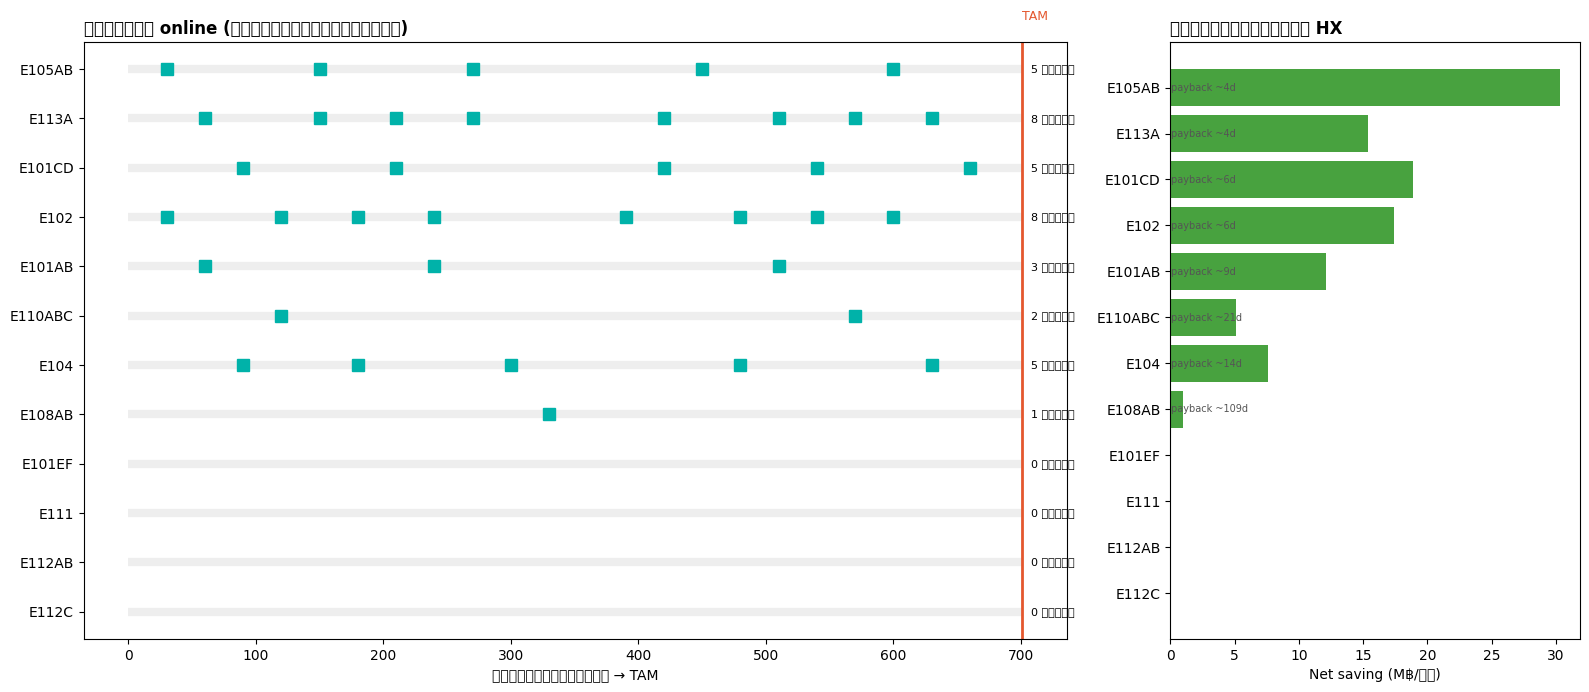

In [8]:
fig, (axg, axb) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})
sub = dec[dec.online].head(12).iloc[::-1]
span = (tam - as_of).days
for i, (_, r) in enumerate(sub.iterrows()):
    axg.hlines(i, 0, span, color='#eee', lw=6)
    for d in (r['scheduled_dates'] or []):
        x = (pd.Timestamp(d) - as_of).days
        axg.plot(x, i, 's', color='#00B2A9', ms=9)
    axg.text(span * 1.01, i, f"{r['n_cleans_to_tam']} ครั้ง", va='center', fontsize=8)
axg.axvline(span, color='#E4572E', lw=2); axg.text(span, len(sub), 'TAM', color='#E4572E', fontsize=9)
axg.set_yticks(range(len(sub))); axg.set_yticklabels(sub.HX)
axg.set_xlabel('วันจากปัจจุบัน → TAM'); axg.set_title('แผนล้าง online (เรียงตามความสำคัญ)', loc='left', fontweight='bold')

axb.barh(range(len(sub)), (sub.net_saving_thb_yr.fillna(0) / 1e6), color='#48A23F')
axb.set_yticks(range(len(sub))); axb.set_yticklabels(sub.HX)
axb.set_xlabel('Net saving (M฿/ปี)'); axb.set_title('ความคุ้มค่าต่อ HX', loc='left', fontweight='bold')
for i, (_, r) in enumerate(sub.iterrows()):
    pb = r['payback_days']
    axb.text(0.05, i, f"payback ~{pb:.0f}d" if pd.notna(pb) else '', va='center', fontsize=7, color='#555')
plt.tight_layout(); plt.savefig(REPO / 'notebooks' / 'fig_cleaning_plan.png', dpi=140, bbox_inches='tight'); plt.show()

## 8 · Export `cleaning_plan.json` (single source for the dashboard)

In [ ]:
def reason(r):
    bits = []
    if r['worth_it'] is False and r['online']: bits.append('⚠ มูลค่าเชื้อเพลิงไม่คุ้มค่าล้างที่ราคานี้')
    if r['payback_days'] and r['payback_days'] < 120: bits.append('คืนทุนเร็ว')
    if r['safety']: bits.append('safety')
    if r['position_risk'] >= 0.8: bits.append('ปลายเทรน (ร้อน/เสี่ยง coking)')
    if r['worsening']: bits.append('แย่ลงต่อเนื่อง')
    if r['online_mode'] == 'ONLINE_PARTIAL': bits.append(f"online ได้บางส่วน ({r['duty_fraction']*100:.0f}%) — อีก shell รอ TAM")
    if not r['online']: bits.append('ไม่มี bypass (list โรงงาน) — รอ TAM')
    return ' · '.join(bits) or 'ตามความคุ้มค่า'

plan = []
for _, r in dec.iterrows():
    plan.append(dict(
        HX=r['HX'], priority_rank=int(r['priority_rank']), online=bool(r['online']),
        online_mode=r['online_mode'], duty_fraction=float(r['duty_fraction']),
        priority_score=float(r['priority_score']),
        fouling_dUrel_per_month=(None if pd.isna(r['fouling_dUrel_per_month']) else float(r['fouling_dUrel_per_month'])),
        rate_source=r['rate_source'],
        T_star_ref_days=(None if pd.isna(r['T_star_ref_days']) else round(float(r['T_star_ref_days']))),
        freq_ref_per_yr=(None if pd.isna(r['freq_ref_per_yr']) else float(r['freq_ref_per_yr'])),
        n_cleans_to_tam=int(r['n_cleans_to_tam']),
        next_clean=r['next_clean'], scheduled_dates=list(r['scheduled_dates'] or []),
        cleaning_cost=(None if pd.isna(r['cleaning_cost']) else int(r['cleaning_cost'])),
        cleaning_cost_overridden=bool(r['cleaning_cost_overridden']),
        fuel_value_per_clean_thb=(None if pd.isna(r['fuel_value_per_clean_thb']) else int(r['fuel_value_per_clean_thb'])),
        worth_it=(None if pd.isna(r['worth_it']) else bool(r['worth_it'])),
        net_saving_thb_yr=(None if pd.isna(r['net_saving_thb_yr']) else int(r['net_saving_thb_yr'])),
        payback_days=(None if pd.isna(r['payback_days']) else round(float(r['payback_days']), 1)),
        cit_gain_C_full=(None if pd.isna(r['cit_gain_C_full']) else float(r['cit_gain_C_full'])),
        cit_gain_C_online=(None if pd.isna(r['cit_gain_C_online']) else float(r['cit_gain_C_online'])),
        cit_gain_source=r['cit_gain_source'],
        safety=bool(r['safety']), worsening=bool(r['worsening']),
        position_risk=float(r['position_risk']), risk_mult=float(r['risk_mult']),
        reason=reason(r),
    ))

out = dict(
    as_of=str(as_of.date()), next_tam=str(tam.date()), next_tam_assumed=False,
    tam_dates=schedV2_full.get('tam_dates'), tam_dates_confirmed=schedV2_full.get('tam_dates_confirmed'),
    per_cycle_summary=schedV2_full.get('per_cycle_summary'),
    v2_full_horizon=schedV2_full.get('v2_full_horizon'),
    cost_overrides_applied=COST_OVERRIDES,
    method=('แผนเดียว: constrained network moving-window optimizer (Dekebo, Oh & Lee 2023) '
            'เคารพ bypass/ทีมล้าง/เพดาน 4-ครั้ง-ต่อปี/TAM (bypass จาก list โรงงานจริง รวมกรณีล้าง online ได้บางส่วน) '
            '· จัดลำดับด้วย net-saving ถ่วงความเสี่ยง (safety, ตำแหน่งเทรน, worsening) · T* เป็นค่าอ้างอิงต่อ HX '
            '· เทียบมูลค่าเชื้อเพลิงเตาที่ประหยัดได้ตรงกับค่าล้าง (worth_it)'),
    constraints=dict(max_freq_per_year=MAX_FREQ, min_interval_days=MIN_INTERVAL,
                     crew_per_month=schedV2.get('max_online_cleans_per_period', 2),
                     online_requires_bypass=True),
    weights=dict(W_SAFETY=W_SAFETY, W_POSITION=W_POSITION, W_WORSENING=W_WORSENING),
    k_baht_per_C_day=round(k_day), feed_kbd=feed_kbd,
    totals=dict(online_hx=int(dec.online.sum()), tam_only=int((~dec.online).sum()),
                partial_online_hx=int((dec.online_mode == 'ONLINE_PARTIAL').sum()),
                total_cleans_to_tam=int(dec[dec.online].n_cleans_to_tam.sum()),
                total_net_saving_thb_yr=int(dec.net_saving_thb_yr.fillna(0).sum())),
    per_hx=plan)
(DASH / 'cleaning_plan.json').write_text(json.dumps(out, ensure_ascii=False, indent=1), encoding='utf-8')
print('Wrote cleaning_plan.json:', len(plan), 'HX ·',
      out['totals']['total_cleans_to_tam'], 'online cleans ·',
      f"{out['totals']['total_net_saving_thb_yr']:,} ฿/yr net")

## 9 · ข้อจำกัดที่ยอมรับตรง ๆ (limitations)

- **online-cleaning capability มาจาก `bypass_config.py` เท่านั้น** (parse ตรงจาก `list bypass Cleaning Heat
  Exchanger.xlsx` — 2026-07-12 fix: เดิมมีลิสต์เขียนมือซ้ำ 2 จุดที่ขัดกับไฟล์จริง แก้แล้ว retire ทิ้ง).
  กรณี "ล้างได้บางส่วน" (`ONLINE_PARTIAL`, เช่น E101CD) ใช้ `duty_fraction` ลดสัดส่วน ΔCIT ที่คืนได้จริงตามจำนวน
  shell ที่ดึงออกมาล้างได้ — ไม่ได้สมมติว่าล้างได้เต็มเหมือนอีกกลุ่ม.
- fouling rate ต่อ HX ใช้รอบ **reliable** ล่าสุด; HX ที่ไม่มีรอบ reliable (spare) inherit จากคู่ตำแหน่งเดียวกัน.
- ΔCIT ต่อการล้าง = ค่าวัดจริง (median audit) ก่อน; fallback ค่าโมเดล (over-estimate ~3×) พร้อม flag.
- **worth_it** เทียบมูลค่าเชื้อเพลิงเตาที่ประหยัดได้ต่อรอบล้าง (k×ΔCIT×T\*/2) กับค่าล้างตรง ๆ — ไม่ใช่แค่ net-saving
  เชิงทฤษฎี แต่เป็นคำตอบตรงคำถาม "คุ้มไหมเทียบเชื้อเพลิงที่เตาใช้จริง".
- ค่าล้างต่อ HX, ทีมล้าง/เดือน, NEXT_TAM เป็น **ค่าสมมติ** รอวิศวกรยืนยัน (ปรับได้ผ่านปุ่ม "คำนวณใหม่" บนแดชบอร์ด
  ซึ่งจะรัน notebook นี้ใหม่ทั้งเซลล์ด้วยค่าที่แก้).
- optimizer ใช้ reduced-form network coupling (ผลรวม CIT-deficit ที่วัดจริง) ไม่ใช่ ε-NTU DAE เต็มรูป — ดู METHODOLOGY §8.2.
- น้ำหนักความเสี่ยง (W_*) เป็นค่าเริ่มต้นที่ปรับได้ ไม่ใช่ค่าตายตัว.